In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data.csv")

In [3]:
data[(data['contrast'] != "Non-contrast") & (data.DICOM_phase == 'Non-contrast')][['contrast', 'DICOM_phase', 'ProtocolName']]

,contrast,DICOM_phase,ProtocolName


In [20]:
data.phase_timing.value_counts()

phase_timing
Just Right      5103
Non-contrast    2118
Too Early        916
0.0              400
Too Late         171
Name: count, dtype: int64

In [ ]:
only_contrast = data[data.contrast.isin(['Arterial', 'Portal']) & (data.phase_timing != 0.0) & (data.phase_timing != "0.0")]

valid_groups = (
    only_contrast
    .groupby(['SubjectKeyRadiology', 'ExamDate'])['contrast']
    .nunique()
    .loc[lambda x: x == 2]   # both Arterial + Portal
    .index
)

both_avail = only_contrast.set_index(['SubjectKeyRadiology', 'ExamDate']).loc[valid_groups].reset_index()                                                                  

,SubjectKeyRadiology,ExamDate,contrast,phase_timing
0,NKI-d23231-00-0002,2015-12-01,Arterial,Too Late
1,NKI-d23231-00-0002,2015-12-01,Portal,Too Early
2,NKI-d23231-00-0005,2010-02-04,Arterial,Too Early
3,NKI-d23231-00-0005,2010-02-04,Portal,Just Right
4,NKI-d23231-00-0005,2012-06-18,Arterial,Too Early
...,...,...,...,...
3726,NKI-d23231-00-0888,2022-04-20,Portal,Just Right
3727,NKI-d23231-00-0888,2023-04-24,Arterial,Just Right
3728,NKI-d23231-00-0888,2023-04-24,Portal,Just Right
3729,NKI-d23231-00-0888,2023-08-01,Arterial,Just Right


In [28]:
both_avail.phase_timing.value_counts()

phase_timing
Just Right    2967
Too Early      703
Too Late        61
Name: count, dtype: int64

In [27]:
both_avail.info()

<class 'pandas.DataFrame'>
RangeIndex: 3731 entries, 0 to 3730
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   SubjectKeyRadiology                 3731 non-null   str    
 1   ExamDate                            3731 non-null   str    
 2   Original File                       3731 non-null   str    
 3   Destination Folder                  3731 non-null   str    
 4   New File                            3731 non-null   str    
 5   file                                3731 non-null   str    
 6   is_liver_imaged                     3731 non-null   str    
 7   contrast                            3731 non-null   str    
 8   phase_timing                        3731 non-null   str    
 9   is_lesionfree                       3731 non-null   str    
 10  ai_segmentation_quality             2481 non-null   float64
 11  manual_segmentation_confidence      2481 non-null   fl

In [42]:
# unique_keys = ["SubjectKeyRadiology"
#                ,"ExamDate"
#                ,"ConvolutionKernel"
#                ,'SliceThickness'
#                ,'BodyPartExamined']

# contrast_data['AcquisitionTime_sec'] = contrast_data['AcquisitionTime'].apply(time_to_seconds)

both_avail["time_interval"] = (
    both_avail
    .groupby(["SubjectKeyRadiology","ExamDate"])["AcquisitionTime_sec"]
    .diff()
    .shift(-1)
    .ffill(limit = 1)
)


both_avail['time_interval'] = both_avail['time_interval'].apply(lambda x: abs(x))
both_avail[both_avail['time_interval'] > 100][['SubjectKeyRadiology', 'ExamDate', 'contrast', 'phase_timing', 'DICOM_phase','ProtocolName', 'AcquisitionTime', 'time_interval']]
both_avail[['SubjectKeyRadiology', 'ExamDate', 'contrast', 'phase_timing', 'AcquisitionTime', 'time_interval']]  

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,time_interval
0,NKI-d23231-00-0002,2015-12-01,Arterial,Too Late,12:03:50.151320,0.00519
1,NKI-d23231-00-0002,2015-12-01,Portal,Too Early,12:03:50.156510,0.00519
2,NKI-d23231-00-0005,2010-02-04,Arterial,Too Early,11:18:35.166000,53.64779
3,NKI-d23231-00-0005,2010-02-04,Portal,Just Right,11:19:28.813790,53.64779
4,NKI-d23231-00-0005,2012-06-18,Arterial,Too Early,14:08:8.950000,33.40000
...,...,...,...,...,...,...
3726,NKI-d23231-00-0888,2022-04-20,Portal,Just Right,15:13:16.119320,31.78189
3727,NKI-d23231-00-0888,2023-04-24,Arterial,Just Right,12:05:45.561000,34.57700
3728,NKI-d23231-00-0888,2023-04-24,Portal,Just Right,12:06:20.138000,34.57700
3729,NKI-d23231-00-0888,2023-08-01,Arterial,Just Right,11:43:20.650000,29.39200


In [43]:
both_avail[["SubjectKeyRadiology"
               ,"ExamDate"
               , "contrast"
               , "phase_timing"
               , "AcquisitionTime"
               , "AcquisitionTime_sec"
               , "time_interval"
               ,"ConvolutionKernel"
               ,'SliceThickness'
               ,'BodyPartExamined']]

,SubjectKeyRadiology,ExamDate,contrast,phase_timing,AcquisitionTime,AcquisitionTime_sec,time_interval,ConvolutionKernel,SliceThickness,BodyPartExamined
0,NKI-d23231-00-0002,2015-12-01,Arterial,Too Late,12:03:50.151320,43430.15132,0.00519,B25f,1.5,ABDOMEN
1,NKI-d23231-00-0002,2015-12-01,Portal,Too Early,12:03:50.156510,43430.15651,0.00519,B31f,3.0,ABDOMEN
2,NKI-d23231-00-0005,2010-02-04,Arterial,Too Early,11:18:35.166000,40715.16600,53.64779,B25f,1.5,ABDOMEN
3,NKI-d23231-00-0005,2010-02-04,Portal,Just Right,11:19:28.813790,40768.81379,53.64779,B25f,1.5,ABDOMEN
4,NKI-d23231-00-0005,2012-06-18,Arterial,Too Early,14:08:8.950000,50888.95000,33.40000,FC02,1.0,ABDOMEN
...,...,...,...,...,...,...,...,...,...,...
3726,NKI-d23231-00-0888,2022-04-20,Portal,Just Right,15:13:16.119320,54796.11932,31.78189,B25f,1.5,ABDOMEN
3727,NKI-d23231-00-0888,2023-04-24,Arterial,Just Right,12:05:45.561000,43545.56100,34.57700,Bv38f\2,1.0,ABDOMEN
3728,NKI-d23231-00-0888,2023-04-24,Portal,Just Right,12:06:20.138000,43580.13800,34.57700,Bv38f\2,1.0,ABDOMEN
3729,NKI-d23231-00-0888,2023-08-01,Arterial,Just Right,11:43:20.650000,42200.65000,29.39200,Bv38f\2,1.0,ABDOMEN


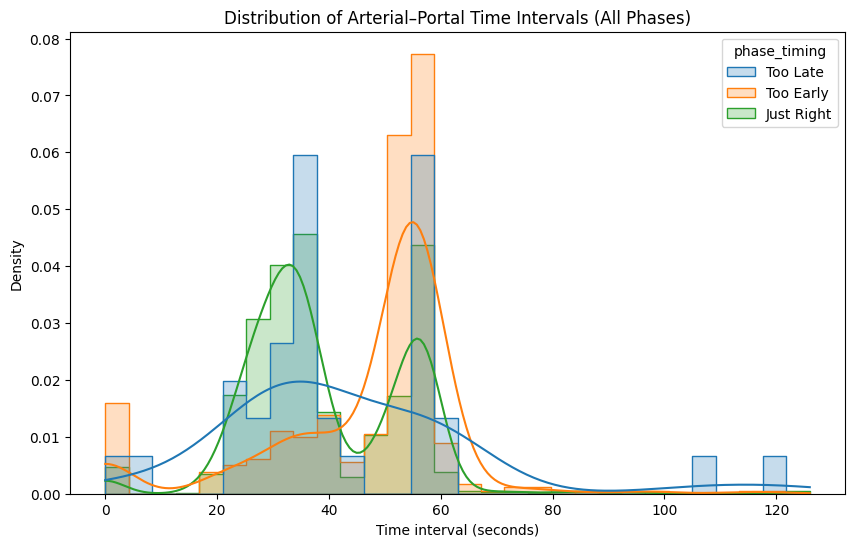

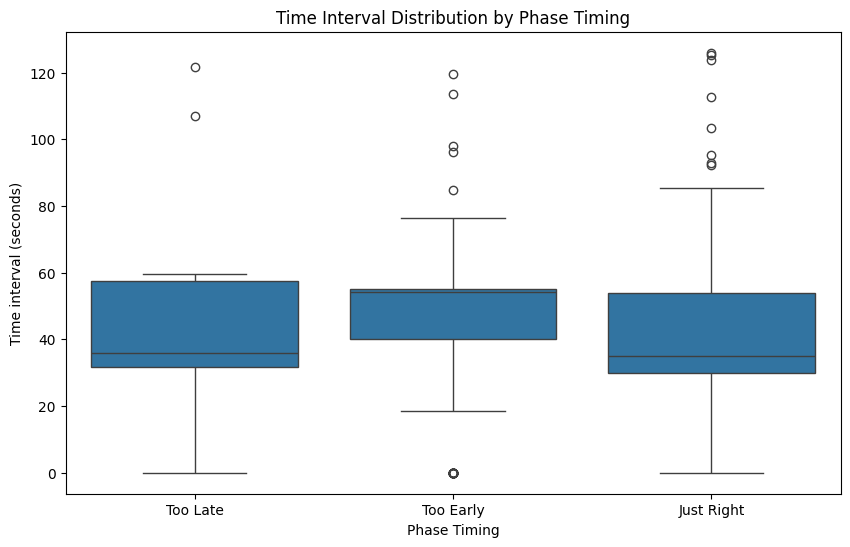

In [44]:
intervals = both_avail.drop_duplicates(subset=['SubjectKeyRadiology', 'ExamDate'])

plt.figure(figsize=(10, 6))
sns.histplot(
    data=intervals,
    x='time_interval',
    hue='phase_timing',
    bins=30,
    kde=True,
    element="step",   # cleaner overlap
    stat="density",   # optional: normalize
    common_norm=False # keep distributions separate
)

plt.xlabel("Time interval (seconds)")
plt.title("Distribution of Arterial–Portal Time Intervals (All Phases)")
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=intervals,
    x='phase_timing',
    y='time_interval'
)

plt.title("Time Interval Distribution by Phase Timing")
plt.xlabel("Phase Timing")
plt.ylabel("Time interval (seconds)")
plt.show()

  SubjectKeyRadiology    ExamDate phase_timing_Arterial phase_timing_Portal  \
0  NKI-d23231-00-0002  2015-12-01              Too Late           Too Early   
1  NKI-d23231-00-0005  2010-02-04             Too Early          Just Right   
2  NKI-d23231-00-0005  2012-06-18             Too Early           Too Early   
3  NKI-d23231-00-0005  2022-05-11            Just Right          Just Right   
4  NKI-d23231-00-0005  2022-10-17            Just Right          Just Right   

   interval              timing_combo  
0   0.00519     Too Late -> Too Early  
1  53.64779   Too Early -> Just Right  
2  33.40000    Too Early -> Too Early  
3  30.84280  Just Right -> Just Right  
4  32.75200  Just Right -> Just Right  


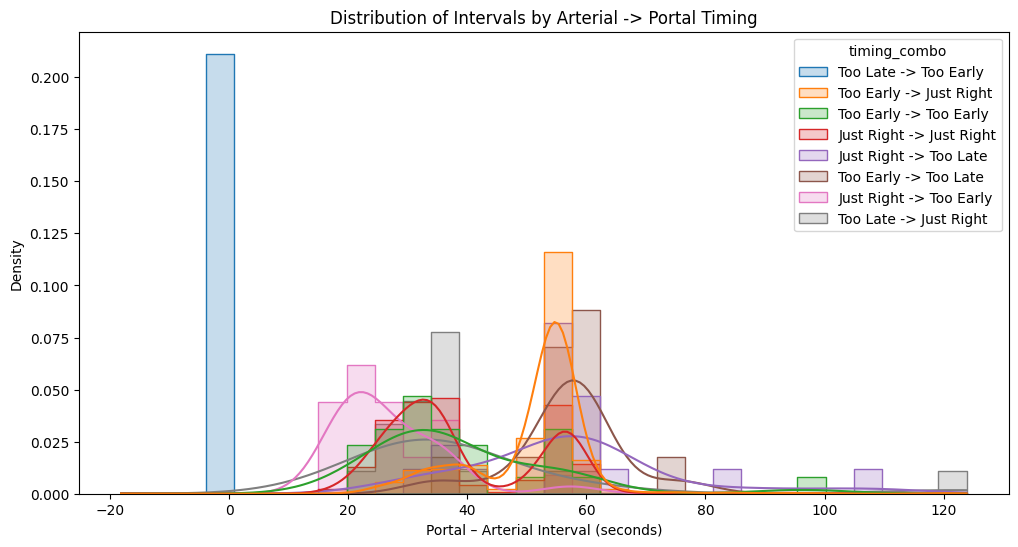

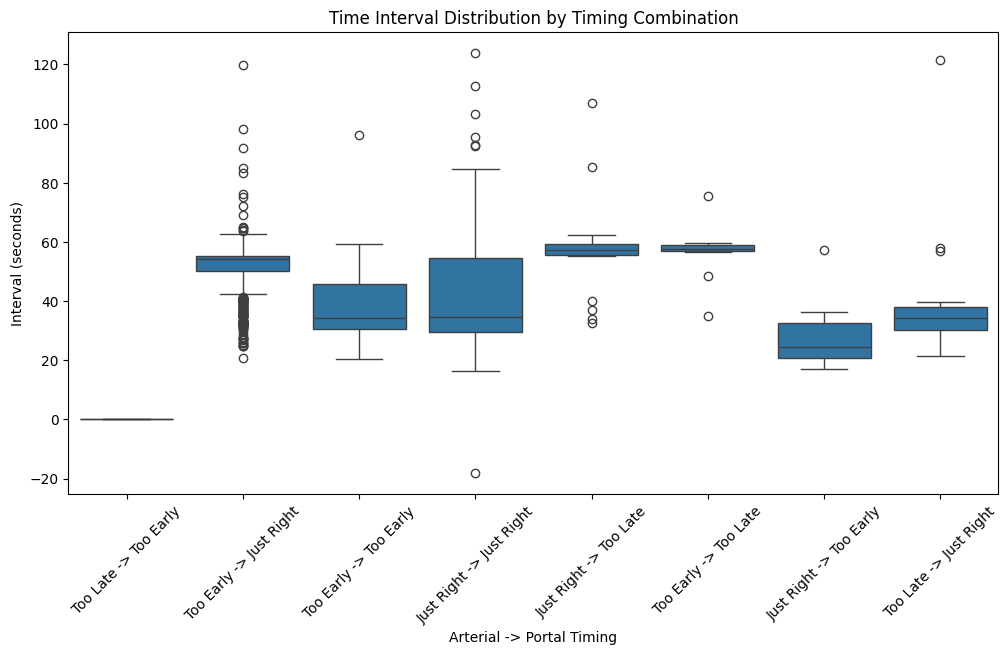

In [47]:
df_wide = both_avail.pivot_table(
    index=['SubjectKeyRadiology', 'ExamDate', 'BodyPartExamined'],
    columns='contrast', 
    values=['AcquisitionTime_sec', 'phase_timing'],
    aggfunc={'AcquisitionTime_sec':'first', 'phase_timing':'first'}  # <--- specify aggregation
).reset_index()

# Flatten column names
df_wide.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_wide.columns]

# Calculate interval: Portal – Arterial
df_wide['interval'] = df_wide['AcquisitionTime_sec_Portal'] - df_wide['AcquisitionTime_sec_Arterial']

# Create combined timing category
df_wide['timing_combo'] = df_wide['phase_timing_Arterial'] + " -> " + df_wide['phase_timing_Portal']

# Check the first few rows
print(df_wide[['SubjectKeyRadiology', 'ExamDate', 'phase_timing_Arterial', 'phase_timing_Portal', 'interval', 'timing_combo']].head())

# -----------------------------
# 1️⃣ Histogram of intervals per timing combination
plt.figure(figsize=(12,6))
sns.histplot(
    data=df_wide,
    x='interval',
    hue='timing_combo',
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)
plt.xlabel("Portal – Arterial Interval (seconds)")
plt.title("Distribution of Intervals by Arterial -> Portal Timing")
plt.show()

# -----------------------------
# 2️⃣ Boxplot of intervals per timing combination
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_wide,
    x='timing_combo',
    y='interval'
)
plt.xticks(rotation=45)
plt.xlabel("Arterial -> Portal Timing")
plt.ylabel("Interval (seconds)")
plt.title("Time Interval Distribution by Timing Combination")
plt.show()